In this tutorial, we would like to demonstrate trace header overlays and crossplots, and also the use of special colormaps provided by the __seisplot__ package. This tutorial requires the __seisio__ package to be available (in order to read field data). The data set used in this example is called Kahu 3D, see https://wiki.seg.org/wiki/Kahu-3D for details.

In [1]:
import logging
import numpy as np

import sys
sys.path.insert(1, '../')

import seisplot
import seisio

# import a colormap similar to opendtect's default seismic colormap
from seisplot.colormaps import opendtect

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s', force=True)

As shown in a previous tutorial, we can easily read data using the __seisio__ package. First, establish an I/O instance, then read all the headers and look at trace header statistics to figure out what we have. A special trace header setup is used, provided via JSON trace header definition table (see the __seisio__ documentation for details).

In [2]:
sio = seisio.input("data/KAHU-3D-PR3177-FM.3D.Final_Migration.sgy",
                   thdef="data/KAHU-3D.json")
headers = sio.read_all_headers()
thstat = sio.log_thstat(traces=headers)

INFO: Input file: data/KAHU-3D-PR3177-FM.3D.Final_Migration.sgy
INFO: SEG-Y textual file header encoding looks to be 'EBCDIC' (best guess).
INFO: Input file endianess looks to be '>' (best guess).
INFO: SEG-Y revision: original SEG-Y conforming to 1975 standard.
INFO: Data sample format: 4-byte IBM floating-point.
INFO: SEG-Y fixed-trace-length flag is set in binary header.
INFO: Number of additional textual header records: 0.
INFO: Number of trailer stanza records: 0.
INFO: SEG-Y trace header extension 1 is not present.
INFO: Number of user-defined trace headers: 0
INFO: Byte offset of first trace relative to start of file: 3600 bytes.
INFO: Number of samples per data trace: 1500.
INFO: Sampling interval: 4000 (unit as per SEG-Y standard).
INFO: Number of data traces in file: 994230.
INFO: Delay (on first trace): 0 (unit as per SEG-Y standard).
INFO: Reading all 994230 trace headers from disk...
INFO: Reading all headers took 4.2 seconds.
INFO: Calculating trace header statistics.
INF

We have a 3D cube with bin coordinates and inline and crossline numbers. This is consistent with the description on the SEG wiki that the data set is a 3D prestack-migrated final volume. To demonstrate header overlays, let's read a single inline, say 1300:

In [3]:
sio.create_index(group_by="iline", sort_by="xline", headers=headers)
iline1300 = sio.read_ensemble(1300)

INFO: Created lookup index for [np.str_('iline')] (order '>').
INFO: Each ensemble is sorted by [np.str_('xline')] (order '>').
INFO: Number of ensembles: 599
INFO: Reading ensemble(s) '1300'.
INFO: Reading 1697 trace(s) from disk starting at trace 515888...


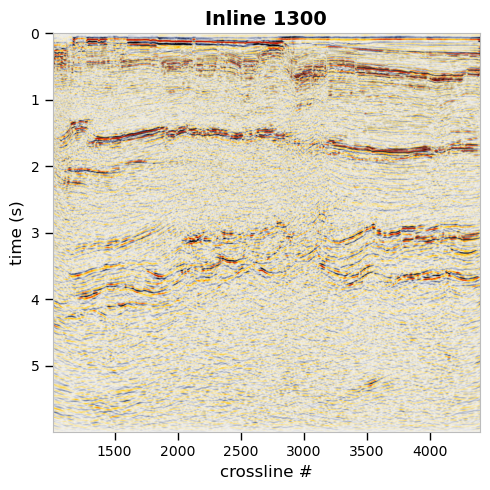

In [4]:
fig, ax = seisplot.plot(iline1300, haxis="xline", hlabel="crossline #", perc=99,
                        vlabel="time (s)", colormap=opendtect(), width=5, height=5,
                        title="Inline 1300")

This looks consistent with the image shown on the SEG wiki. Note that we have used a special non-standard Matplotlib colormap in this example. We could now plot another trace header mnemonic on top by simply specifying 'overlay=mnemonic' (mnemonic being an actually available trace header mnemonic). We can also provide the keyword 'rms' in order to overlay the RMS amplitude value of each trace. Let's try this:

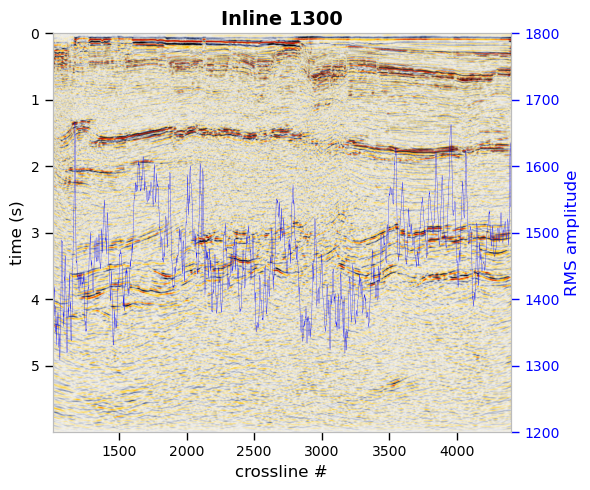

In [5]:
fig, ax = seisplot.plot(iline1300, haxis="xline", hlabel="crossline #", perc=99,
                        vlabel="time (s)", colormap=opendtect(), width=6, height=5,
                        title="Inline 1300", overlay="rms", overlaylinewidth=0.2,
                        overlaycolor="blue", overlaylabel="RMS amplitude",
                        overlayaxisbeg=1200, overlayaxisend=1800)

That was pretty easy. Let's read the whole data set so we can create a crossplot.

In [6]:
dataset = sio.read_dataset()

INFO: Reading entire file (994230 traces) from disk...
INFO: Reading all traces took 1.2 seconds.
INFO: Converting IBM floats to IEEE floats.


Here we create a crossplot of inline vs. crossline, colored by each trace's RMS amplitude value. We also add a histogram at the top of the crossplot to show how the RMS values are distributed. The histogram itself is colored using the same colormap and range as used for the colorbar. The number of histogram bins is determined automatically but we could also set the number of bins directly. The rest of the parameters probably looks familiar in case you have worked through previous examples.

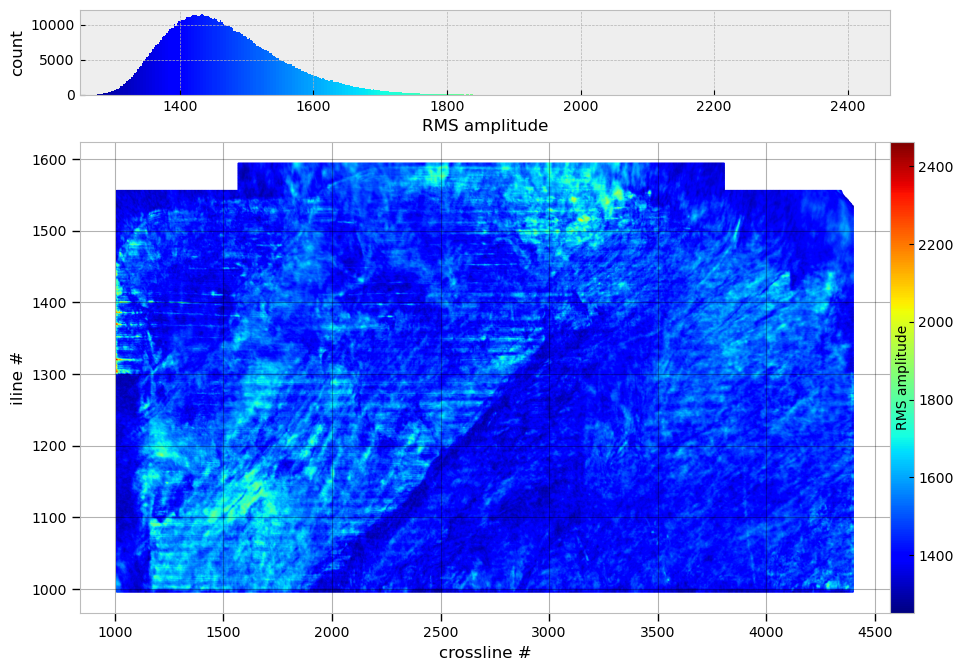

In [7]:
fig, ax = seisplot.crossplot(dataset, hkey="xline", vkey="iline", color_by="rms", 
                             width=10, height=7, hlabel="crossline #", vlabel="iline #", 
                             colorbar=True, colorbarlabel="RMS amplitude",
                             colorbarlabelpad=-42, colorbarpad=0, markersize=1,
                             histogram=True, histogram_colorize=True, histogram_vpos=1.1,
                             histogram_bins="auto", vgrid="major", hgrid="major",
                             gridlinealpha=0.3)

This concludes the current example.